## Scalings

Here we check how the code behaves as the problem size is increased.

In [1]:
import jax_rmhd as jr
import jax
from jax import jit
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
from jax_rmhd.run import block_of_steps
import timeit
jr.init_cluster()

rmhd-solver has initialized jax in 64bit precision.
Running in local mode. Total devices: 1


In [2]:
#parameters
Lx = Ly = 2.0*jnp.pi
nupar = 1e-4
dt = 0.01
t = 0.0
nblock = 10
cfl_safety=1.0 #this is pretty aggressive
visc=1e-9
res=1e-9
hyper=3
dims=2

In [5]:
resolutions = [32,64,128,256,512,1024,2048]
results= []

for n in resolutions:
    print(n)
    x = jnp.linspace(0, Lx, n, endpoint=False)
    y = jnp.linspace(0, Ly, n, endpoint=False)
    x_grid = x.reshape(-1,1)
    y_grid = y.reshape(1,-1)

    #setting fields to zero: we just check scalings of the code with no effect from the physics
    phi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)
    psi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)

    #fft
    phik=ft.rfft2(phi)
    psik=ft.rfft2(psi)
    params=jr.Parameters(nx=n,ny=n,Lx=Lx,Ly=Ly,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety)
    _,_,state_sharding=jr.setup_sharding(params)
    kgrid = jr.setup_kgrids(params)
    state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))
    #jit-compile block_of_steps
    block_of_steps_jit = jax.jit(block_of_steps,static_argnums=(2,3),
                           in_shardings=(state_sharding, None),
                             out_shardings=(state_sharding,None))
    #warmup jit
    block = lambda: jax.block_until_ready(block_of_steps_jit(state, kgrid, params, nblock))
    _ = jax.block_until_ready(block_of_steps_jit(state, kgrid, params, nblock))
    raw_times=jnp.array(timeit.repeat(block,number=1,repeat=10))
    results.append((jnp.mean(raw_times),jnp.std(raw_times)))

32
---COMPILING rk_advance---
64
---COMPILING rk_advance---
128
---COMPILING rk_advance---
256
---COMPILING rk_advance---
512
---COMPILING rk_advance---
1024
---COMPILING rk_advance---
2048
---COMPILING rk_advance---


Text(300.0, 0.003, '$\\propto n^2 log(n)$')

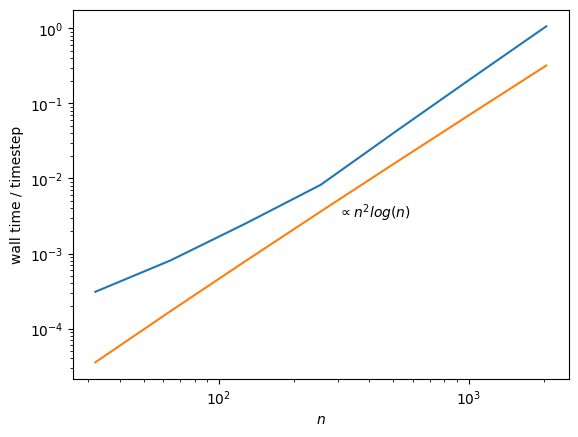

In [6]:
resultarr=jnp.array(results)/nblock
resolutionarr=jnp.array(resolutions)
plt.loglog(resolutionarr,resultarr[:,0])
plt.loglog(resolutionarr,1e-8*resolutionarr**2 * jnp.log(resolutionarr))
plt.xlabel(r'$n$')
plt.ylabel(r'wall time / timestep')
plt.text(3e2,3e-3,r'$\propto n^2 log(n)$')

The scaling for large n follows the expected scaling for 2D FFT (shown in orange).

Now let's see check how things change as we vary `nblock`. The reason for doing this is that depending on algorithm the XLA compiler can sometimes fuse across timesteps, improving performance. In our case, it does not seem like this is possible, but this could be checked on different machines.

In [11]:
n=256

x = jnp.linspace(0, Lx, n, endpoint=False)
y = jnp.linspace(0, Ly, n, endpoint=False)
x_grid = x.reshape(-1,1)
y_grid = y.reshape(1,-1)

#setting fields to zero: we just check scalings of the code with no effect from the physics
phi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)
psi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)
params=jr.Parameters(nx=n,ny=n,Lx=Lx,Ly=Ly,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety)
_,_,state_sharding=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

blocklengths = [1, 5, 10, 50, 100, 200, 500, 1000]
results = []

for nb in blocklengths:
    print(nb)
    block_of_steps_jit = jax.jit(block_of_steps,static_argnums=(2,3),
                           in_shardings=(state_sharding, None),
                             out_shardings=(state_sharding,None))
    block = lambda: jax.block_until_ready(block_of_steps_jit(state, kgrid, params, nb))
    #warm up jit
    _ = jax.block_until_ready(block_of_steps_jit(state, kgrid, params, nb))
    _ = jax.block_until_ready(block_of_steps_jit(state, kgrid, params, nb))
    raw_times=jnp.array(timeit.repeat(block,number=1,repeat=10))
    results.append((jnp.mean(raw_times)/nb,jnp.std(raw_times)/nb))

    
resultarr=jnp.array(results)
nbarr=jnp.array(blocklengths)


1
---COMPILING rk_advance---
5
---COMPILING rk_advance---
10
---COMPILING rk_advance---
50
---COMPILING rk_advance---
100
---COMPILING rk_advance---
200
---COMPILING rk_advance---
500
---COMPILING rk_advance---
1000
---COMPILING rk_advance---


Text(0, 0.5, 'wall time / timestep')

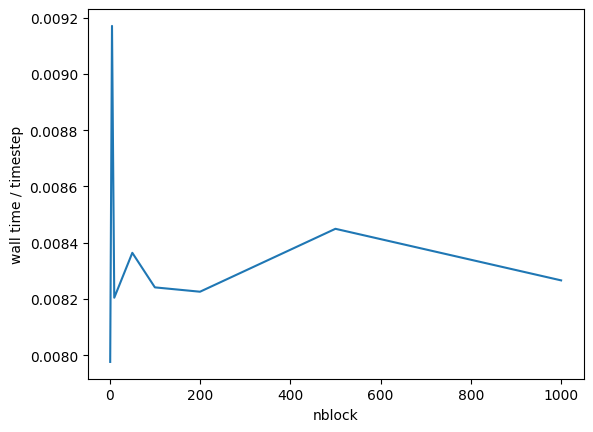

In [12]:
plt.plot(nbarr,resultarr[:,0])
plt.xlabel(r'nblock')
plt.ylabel(r'wall time / timestep')
#plt.ylim(0,0.02)
